# **Problem Statement**

**Problem Statement**

Yulu, India’s leading micro-mobility service provider, is experiencing a decline in revenue, which is directly tied to reduced demand for its shared electric cycles.

**Core Objective**

To identify and analyze the key factors influencing demand (count of rented cycles) in the Indian market.

**Key Business Questions**

Which variables significantly affect the demand for shared electric cycles?
How do environmental and calendar factors (weather, season, working day, etc.) impact usage?
How well can these variables explain variations in demand?

#**Data Understanding & Structure**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
!gdown 10KvP8DQPTZXH-CZColMGpEtcUZvS3s3v

Downloading...
From: https://drive.google.com/uc?id=10KvP8DQPTZXH-CZColMGpEtcUZvS3s3v
To: /content/yulu_bike.csv
100% 648k/648k [00:00<00:00, 9.34MB/s]


In [ ]:
df = pd.read_csv('yulu_bike.csv')

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
df.shape

(10886, 12)

In [ ]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
cat_cols = ['season', 'holiday', 'workingday', 'weather']

for col in cat_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   datetime    10886 non-null  object  
 1   season      10886 non-null  category
 2   holiday     10886 non-null  category
 3   workingday  10886 non-null  category
 4   weather     10886 non-null  category
 5   temp        10886 non-null  float64 
 6   atemp       10886 non-null  float64 
 7   humidity    10886 non-null  int64   
 8   windspeed   10886 non-null  float64 
 9   casual      10886 non-null  int64   
 10  registered  10886 non-null  int64   
 11  count       10886 non-null  int64   
dtypes: category(4), float64(3), int64(4), object(1)
memory usage: 723.7+ KB


In [ ]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [ ]:
df.describe()

,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [ ]:
df.describe(include='all')

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.0,10886.0,10886.0,10886.0,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
unique,10886,4.0,2.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2012-12-19 23:00:00,4.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,2734.0,10575.0,7412.0,7192.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,NaN,NaN,NaN,NaN,NaN,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,NaN,NaN,NaN,NaN,NaN,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,NaN,NaN,NaN,NaN,NaN,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,NaN,NaN,NaN,NaN,NaN,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000


In [ ]:
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: season
season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64

Column: holiday
holiday
0    10575
1      311
Name: count, dtype: int64

Column: workingday
workingday
1    7412
0    3474
Name: count, dtype: int64

Column: weather
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,day,month,year
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,1,1,2011
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,1,2011
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,1,1,2011
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,1,1,2011
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,1,1,2011


**Observations**
1. The dataset contains 10,886 records and 12 variables, providing a sufficiently large sample for robust exploratory and statistical analysis.

2. Variables are appropriately classified into dependent (count), categorical (season, holiday, workingday, weather), continuous (temp, atemp, humidity, windspeed), and time-based features, with categorical conversion improving data readiness for hypothesis testing.

3. There are no missing values and no duplicate records, indicating strong data quality with no need for cleaning interventions.

4. Demand (count) shows high variability, likely right-skewness, and potential high-end outliers, suggesting rentals are not uniformly distributed.

5. Continuous variables show broad operating ranges, while potential outliers may exist in count and windspeed, and possible multicollinearity may exist between temp and atemp.

6. season and workingday have adequate group balance for comparison, while holiday is highly imbalanced and weather category 4 has only one observation, creating limitations for inference.

7. Preliminary evidence suggests demand may be influenced by environmental and calendar factors, while sparse severe-weather data may require special treatment during statistical testing.

**Univariate Analysis**

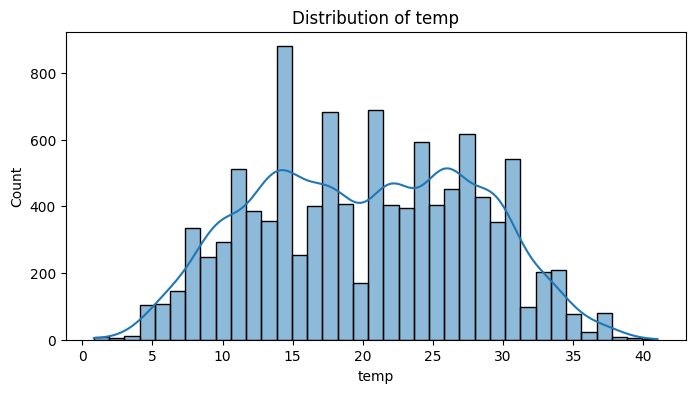

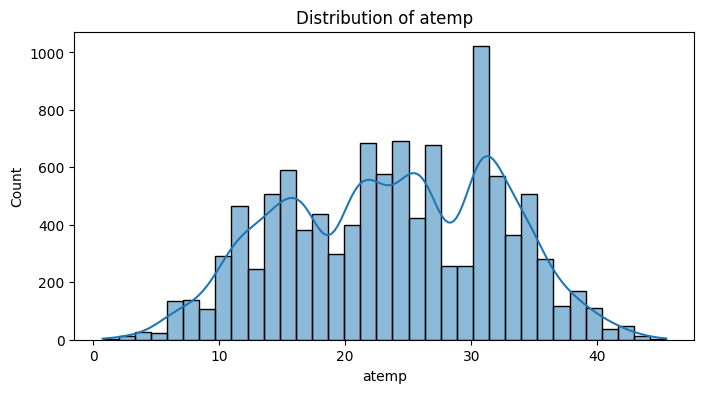

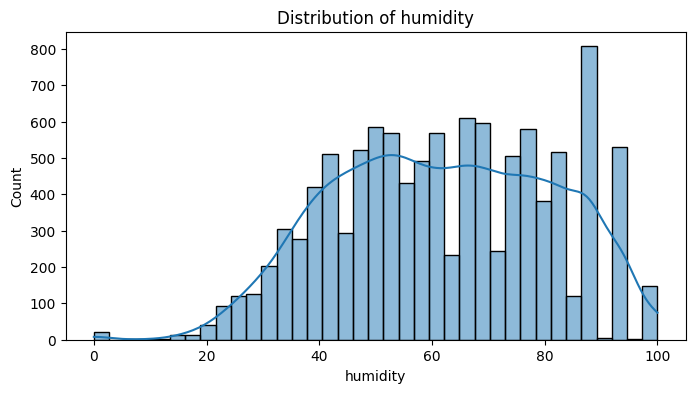

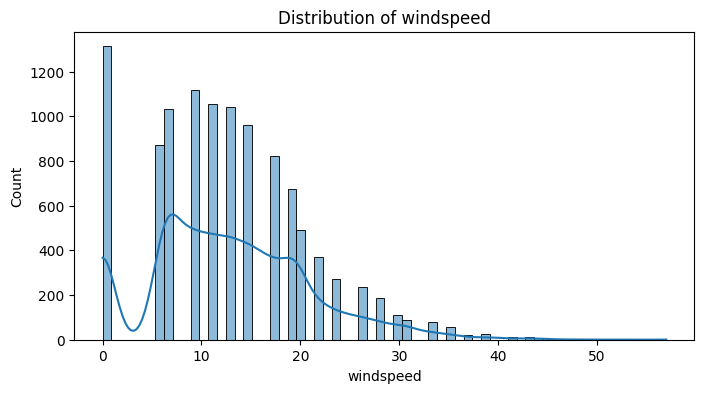

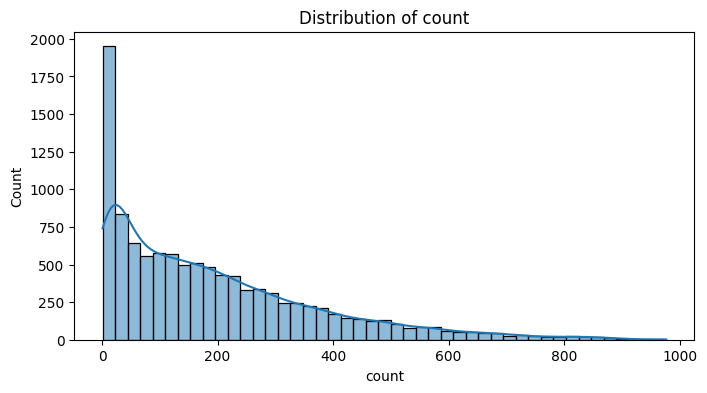

In [ ]:
cont_cols=['temp','atemp','humidity','windspeed','count']

for col in cont_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

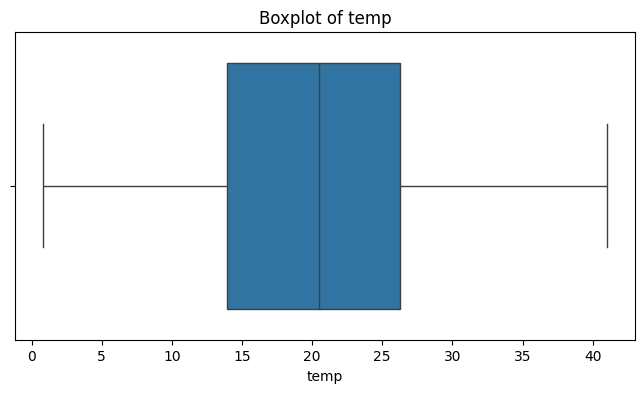

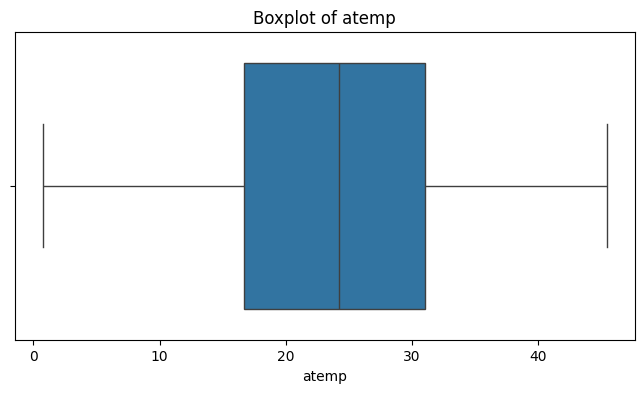

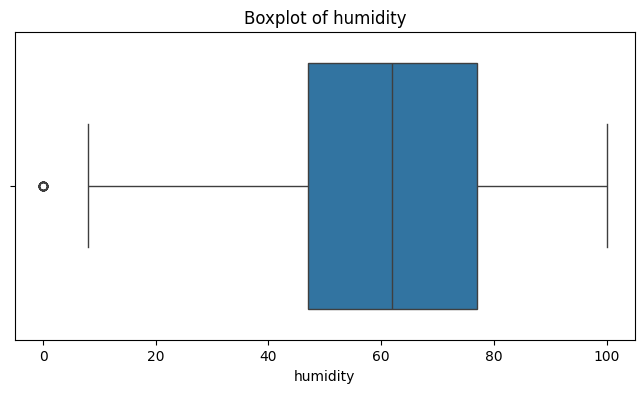

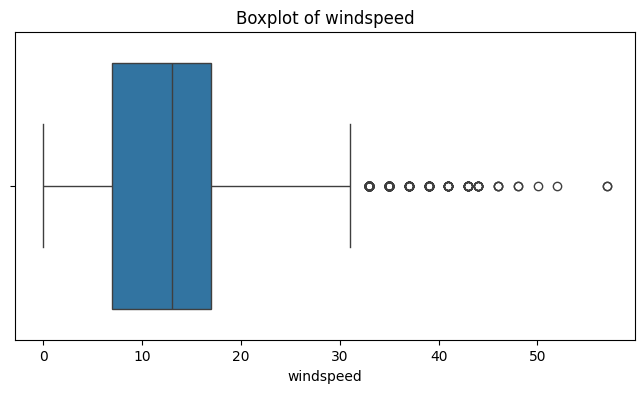

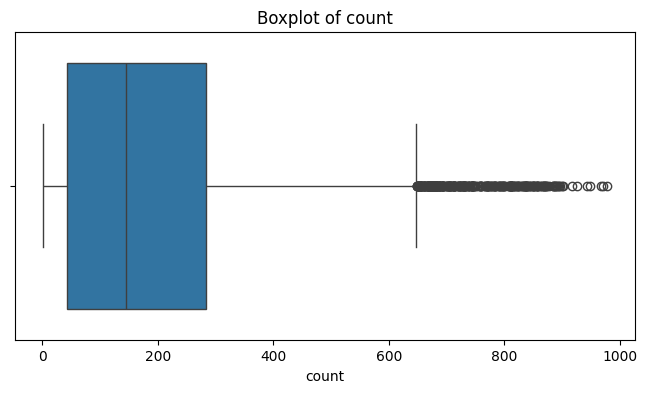

In [ ]:
for col in cont_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
for col in cont_cols:
    print(col, df[col].skew())

temp 0.003690844422472008
atemp -0.10255951346908665
humidity -0.08633518364548581
windspeed 0.5887665265853944
count 1.2420662117180776


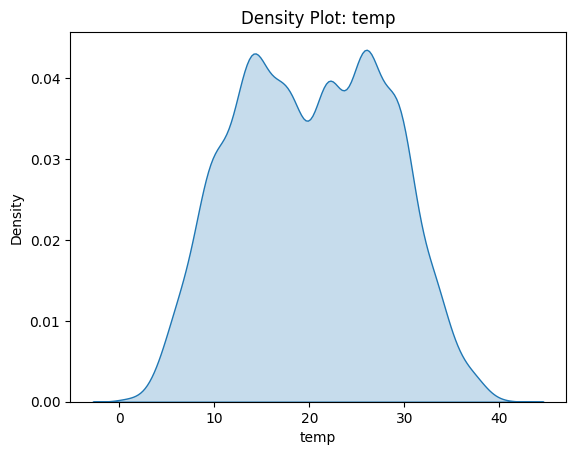

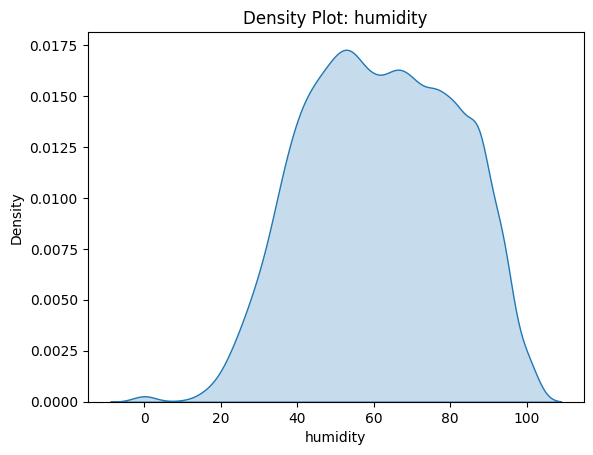

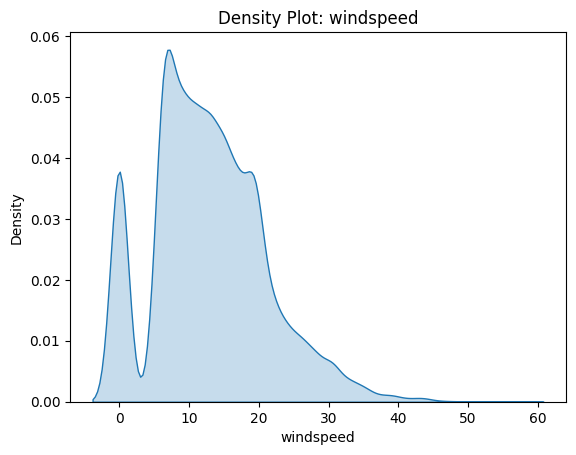

In [ ]:
for col in ['temp','humidity','windspeed']:
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Density Plot: {col}')
    plt.show()

**Observation**

1. Temp and atemp show approximately symmetric distributions (skewness near 0), indicating near-normal behavior, while temperature is spread across a broad but realistic operating range.

2. Humidity shows moderate concentration around mid-to-high values with limited skewness, suggesting humidity levels are fairly stable across observations.

3. Windspeed exhibits positive skew (0.589) and boxplot outliers, indicating most observations occur at lower wind speeds with fewer extreme conditions.

4. The target variable count shows strong positive skew (1.242) and significant upper-end outliers, indicating rental demand is unevenly distributed with occasional demand spikes.

5. Boxplots indicate outlier presence primarily in count and windspeed, while temp, atemp, and humidity appear relatively stable without severe anomalies.

6. Countplots show balanced distributions for season, adequate representation for workingday, strong imbalance in holiday, and dominance of clear-weather observations, while severe weather remains too sparse for reliable standalone inference.

7. Overall, univariate analysis suggests environmental variables are reasonably well-behaved, while demand (count) is non-normal and variable, supporting the need for careful assumption checks in later hypothesis testing.

**Bivariate Analysis**

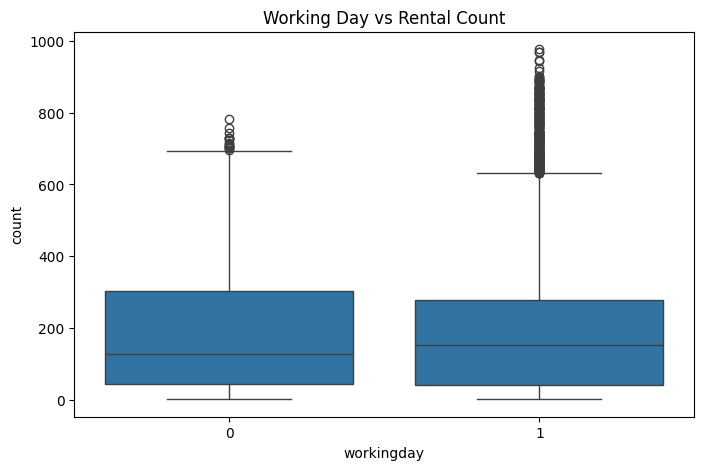

,count,mean,std,min,25%,50%,75%,max
workingday,,,,,,,,
0,3474.0,188.506621,173.724015,1.0,44.0,128.0,304.0,783.0
1,7412.0,193.011873,184.513659,1.0,41.0,151.0,277.0,977.0


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='workingday', y='count', data=df)
plt.title('Working Day vs Rental Count')
plt.show()

df.groupby('workingday')['count'].describe()

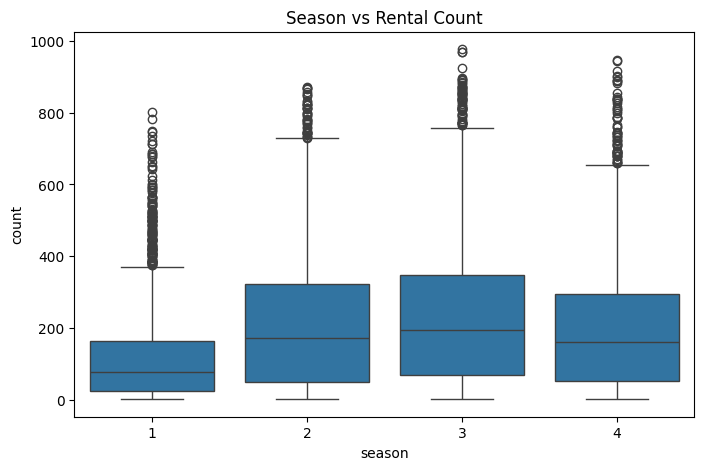

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='season', y='count', data=df)
plt.title('Season vs Rental Count')
plt.show()

df.groupby('season')['count'].describe()

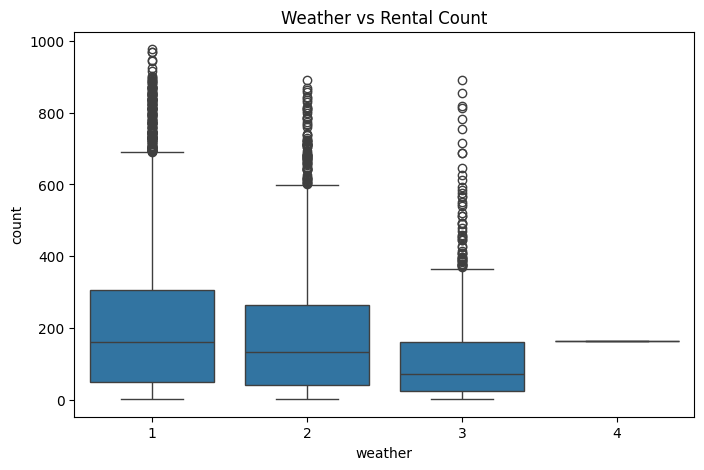

,count,mean,std,min,25%,50%,75%,max
weather,,,,,,,,
1,7192.0,205.236791,187.959566,1.0,48.0,161.0,305.0,977.0
2,2834.0,178.955540,168.366413,1.0,41.0,134.0,264.0,890.0
3,859.0,118.846333,138.581297,1.0,23.0,71.0,161.0,891.0
4,1.0,164.000000,NaN,164.0,164.0,164.0,164.0,164.0


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='weather', y='count', data=df)
plt.title('Weather vs Rental Count')
plt.show()

df.groupby('weather')['count'].describe()

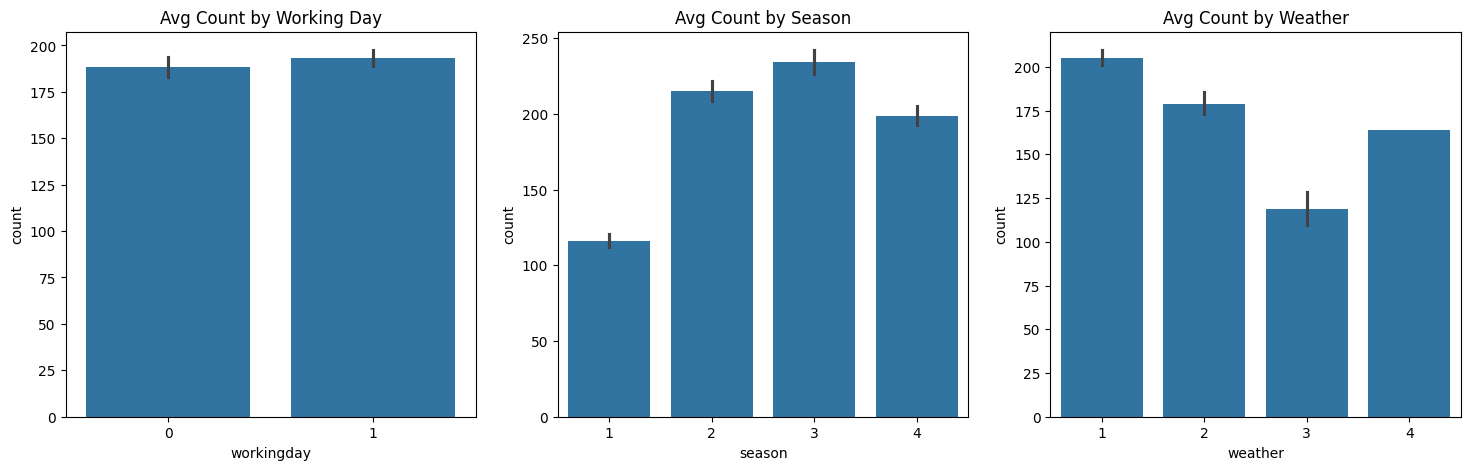

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.barplot(x='workingday', y='count', data=df, ax=axes[0])
axes[0].set_title('Avg Count by Working Day')

sns.barplot(x='season', y='count', data=df, ax=axes[1])
axes[1].set_title('Avg Count by Season')

sns.barplot(x='weather', y='count', data=df, ax=axes[2])
axes[2].set_title('Avg Count by Weather')

plt.show()

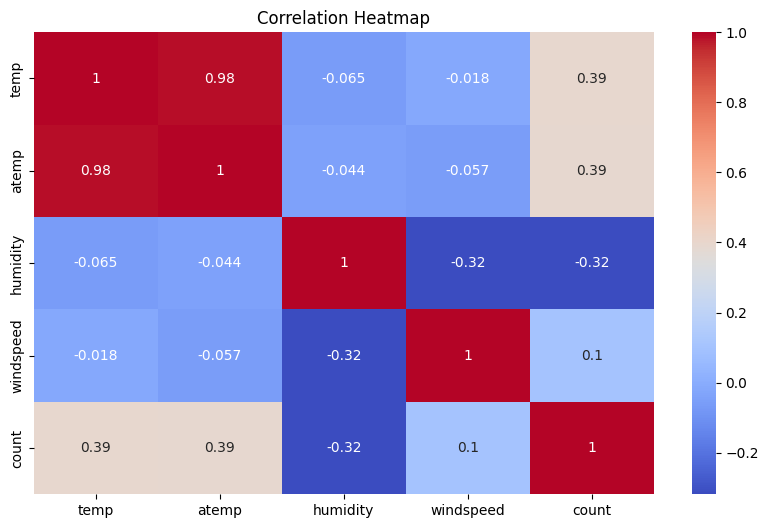

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[['temp','atemp','humidity','windspeed','count']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

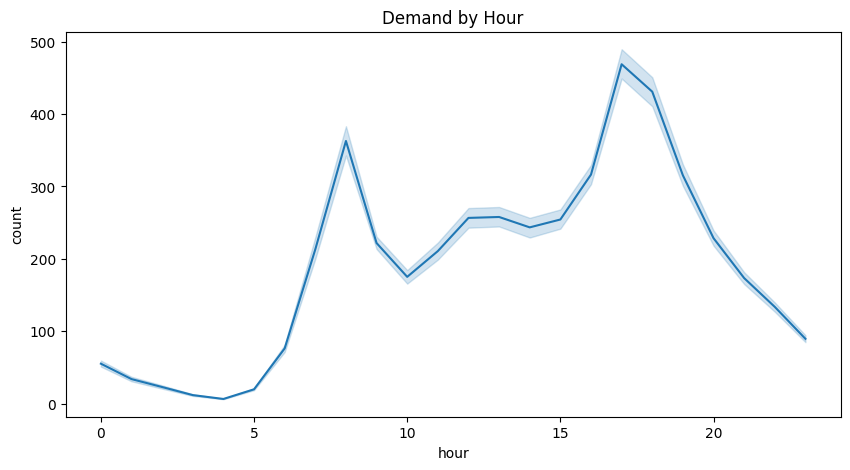

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x='hour', y='count', data=df)
plt.title('Demand by Hour')
plt.show()

**Observations**

1. Seasonal Variation: Rental demand is highest in Season 3 (Fall) and Season 2 (Summer), while Season 1 (Spring) exhibits the lowest usage, suggesting a strong preference for warmer and more stable months.

2. Weather Sensitivity: Demand shows a clear downward trend as weather conditions worsen; Weather 1 (Clear) sees the highest usage, while Weather 3 (Light Rain/Snow) experiences a sharp drop in rentals.

3. Working Day vs. Weekend: The average rental counts are relatively similar between working and non-working days, though working days show a slightly higher median, indicating consistent utility across the week.

4. Commuter Behavior: The hourly demand curve reveals a distinct bimodal pattern with sharp peaks during morning (8 AM) and evening (5–6 PM) rush hours, confirming heavy reliance on Yulu for daily commutes.

5. Positive Temperature Influence: There is a moderate positive correlation between temperature (temp/atemp) and rental counts, implying that demand naturally increases as the weather becomes warmer.

6. Negative Humidity Impact: Humidity exhibits a notable negative correlation with demand, suggesting that higher humidity levels (often associated with rain or discomfort) discourage users from renting.

7. Feature Redundancy: A near-perfect correlation exists between temp and atemp, indicating multicollinearity. This suggests that these two variables provide redundant information for future modeling.

8. Resilient Demand Spikes: Boxplots across all categories (Season, Weather, Working Day) consistently show significant upper-end outliers, indicating that high-demand spikes can occur even in sub-optimal conditions.

**EDA observations**

1. Attribute Ranges and Outliers
- Temperature Range: Actual and "feels-like" temperatures vary from 0.8°C to 45°C, covering diverse Indian weather conditions.
- Humidity & Windspeed: Humidity levels span the full scale (0–100%), while windspeed shows a narrower range with a median around 13 km/h.
- Target Variable Outliers: The count attribute has significant upper-end outliers, with demand peaking at 977 rentals per hour.
- Windspeed Anomalies: Boxplots reveal several outliers in windspeed, indicating occasional high-velocity wind events.
- Stable Variables: temp, atemp, and humidity show no extreme outliers, suggesting consistent environmental recording.

2. Distributions and Relationships
- Count Distribution: Rental demand is strongly right-skewed, meaning low-to-moderate demand is frequent, while high-volume hours are rare.
- Normal-like Predictors: temp and atemp follow a near-symmetric distribution, making them well-behaved for statistical modeling.
- Multicollinearity: A near-perfect correlation (0.98) exists between temp and atemp, indicating they provide redundant information.
- Inverse Relationships: Humidity shares a negative correlation with demand, as higher moisture levels typically deter riders.
- Positive Climate Impact: Temperature shows a moderate positive correlation with rentals, with demand rising as weather warms.

3. Univariate and Bivariate Plot Insights
- Seasonal Peaks: Bar plots show Fall (Season 3) and Summer (Season 2) are peak periods, while Spring (Season 1) is the slowest.
- Weather Impact: Usage is highest during Clear (Weather 1) conditions and drops drastically during Rain/Snow (Weather 3).
- Commuter Peaks: Hourly line plots reveal a bimodal pattern with sharp spikes at 8 AM and 5–6 PM, signaling commuter usage.
- Working Day Consistency: Boxplots show similar median usage on working and non-working days, though working days have higher extreme peaks.
- Data Imbalance: Countplots highlight a significant shortage of data for Weather 4 (Heavy Rain/Ice), limiting its statistical reliability.

# **Hypothesis Testing**

**2- Sample T-Test**

In [ ]:
df.groupby('workingday')['count'].describe()

,count,mean,std,min,25%,50%,75%,max
workingday,,,,,,,,
0,3474.0,188.506621,173.724015,1.0,44.0,128.0,304.0,783.0
1,7412.0,193.011873,184.513659,1.0,41.0,151.0,277.0,977.0


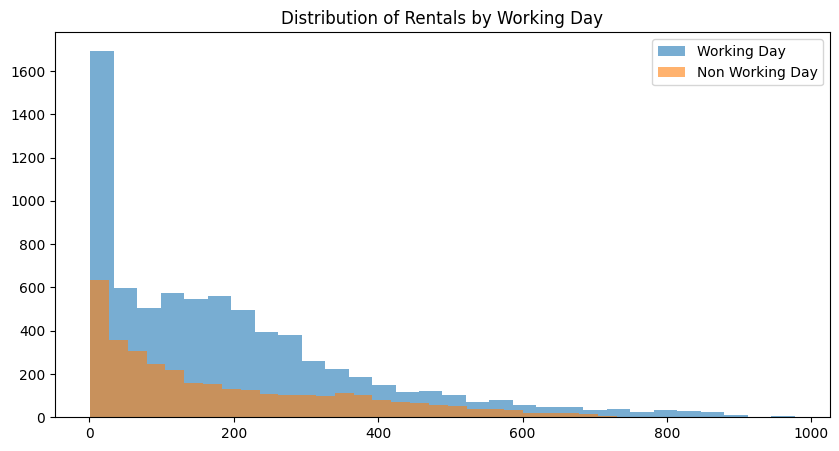

In [ ]:
working = df[df['workingday']==1]['count']
non_working = df[df['workingday']==0]['count']

plt.figure(figsize=(10,5))

plt.hist(working, bins=30, alpha=0.6, label='Working Day')
plt.hist(non_working, bins=30, alpha=0.6, label='Non Working Day')

plt.legend()
plt.title('Distribution of Rentals by Working Day')
plt.show()

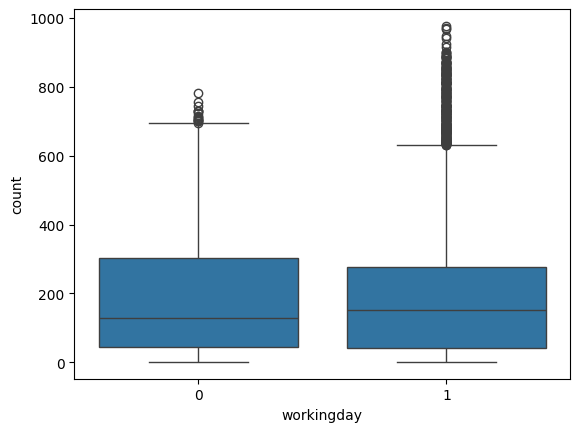

In [ ]:
sns.boxplot(x='workingday', y='count', data=df)
plt.show()

In [ ]:
from scipy.stats import shapiro

print(shapiro(working.sample(500, random_state=42)))
print(shapiro(non_working.sample(500, random_state=42)))

ShapiroResult(statistic=np.float64(0.8723803976429698), pvalue=np.float64(8.020070098537695e-20))
ShapiroResult(statistic=np.float64(0.867359447614823), pvalue=np.float64(3.4189745013780254e-20))


In [ ]:
from scipy.stats import levene

levene(working, non_working)

LeveneResult(statistic=np.float64(0.004972848886504472), pvalue=np.float64(0.9437823280916695))

In [ ]:
mean1=np.mean(working)
mean2=np.mean(non_working)

sd1=np.std(working, ddof=1)
sd2=np.std(non_working, ddof=1)

pooled=np.sqrt((sd1**2 + sd2**2)/2)

cohens_d=(mean1-mean2)/pooled
print(cohens_d)

0.025140906751654757


H₀: Mean rentals on working days = mean rentals on non-working days

H₁: Mean rentals on working days ≠ mean rentals on non-working days

Significance level: α=0.05

**2-Sample T-Test Observations**
1. Marginal Mean Difference: Average rentals on working days (193.01) and non-working days (188.51) show a very narrow gap of only ~4.5 units.

2. Violation of Normality: Shapiro-Wilk tests for both groups yield $p < \alpha$, statistically confirming that the rental counts are not normally distributed.

3. Equality of Variance: A Levene’s test p-value of 0.94 ($p > \alpha$) indicates that the assumption of equal variance between the two groups is satisfied.

4. Trivial Effect Size: The Cohen’s d of 0.025 suggests that even if a statistical difference exists, its practical impact on business demand is negligible.

5. High Data Overlap: Distribution plots and boxplots show nearly identical spreads, suggesting "Working Day" is likely not a significant driver of total volume.

6. Resilient Peak Demand: Both groups exhibit significant outliers (up to 977), indicating that peak usage occurs independently of the day being a working day or weekend.

**ANNOVA for seasons**

H₀: Mean rentals are equal across all seasons

H₁: At least one season has a different mean rental demand.

Significance level: α=0.05

In [ ]:
df.groupby('season')['count'].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


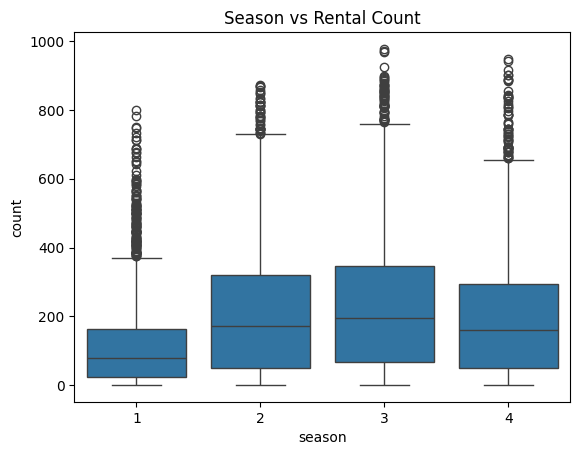

In [ ]:
sns.boxplot(x='season', y='count', data=df)
plt.title('Season vs Rental Count')
plt.show()

In [ ]:
from scipy.stats import shapiro

for s in sorted(df['season'].unique()):
    sample=df[df['season']==s]['count'].sample(500, random_state=42)
    print("Season",s, shapiro(sample))

Season 1 ShapiroResult(statistic=np.float64(0.8610648369491145), pvalue=np.float64(1.2137096897978967e-20))
Season 2 ShapiroResult(statistic=np.float64(0.894413967068355), pvalue=np.float64(4.668666999680628e-18))
Season 3 ShapiroResult(statistic=np.float64(0.9175356147818557), pvalue=np.float64(6.873975175821174e-16))
Season 4 ShapiroResult(statistic=np.float64(0.8806076593396468), pvalue=np.float64(3.4270386455092693e-19))


In [ ]:
from scipy.stats import levene

g1=df[df.season==1]['count']
g2=df[df.season==2]['count']
g3=df[df.season==3]['count']
g4=df[df.season==4]['count']

levene(g1,g2,g3,g4)

LeveneResult(statistic=np.float64(187.7706624026276), pvalue=np.float64(1.0147116860043298e-118))

In [ ]:
from scipy.stats import f_oneway

f_oneway(g1,g2,g3,g4)

F_onewayResult(statistic=np.float64(236.94671081032098), pvalue=np.float64(6.164843386499654e-149))

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df['count'],
    groups=df['season'],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     1      2  98.9081    0.0  86.6544 111.1618   True
     1      3 118.0739    0.0 105.8202 130.3276   True
     1      4   82.645    0.0  70.3924  94.8976   True
     2      3  19.1658 0.0003   6.9653  31.3662   True
     2      4 -16.2631 0.0034 -28.4624  -4.0637   True
     3      4 -35.4288    0.0 -47.6282 -23.2295   True
------------------------------------------------------


In [ ]:
df_weather = df[df['weather'] != 4] #Remove weather category 4

In [ ]:
df_weather.groupby('weather')['count'].describe()

,count,mean,std,min,25%,50%,75%,max
weather,,,,,,,,
1,7192.0,205.236791,187.959566,1.0,48.0,161.0,305.0,977.0
2,2834.0,178.955540,168.366413,1.0,41.0,134.0,264.0,890.0
3,859.0,118.846333,138.581297,1.0,23.0,71.0,161.0,891.0
4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


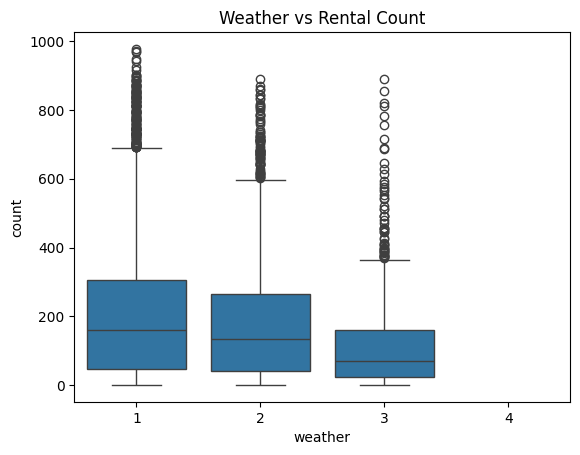

In [ ]:
sns.boxplot(x='weather', y='count', data=df_weather)
plt.title('Weather vs Rental Count')
plt.show()

In [ ]:
for w in sorted(df_weather['weather'].unique()):
    sample=df_weather[df_weather['weather']==w]['count'].sample(500, random_state=42)
    print("Weather",w, shapiro(sample))

Weather 1 ShapiroResult(statistic=np.float64(0.8709383856244287), pvalue=np.float64(6.26244864523398e-20))
Weather 2 ShapiroResult(statistic=np.float64(0.9005330982723817), pvalue=np.float64(1.6096484425494253e-17))
Weather 3 ShapiroResult(statistic=np.float64(0.7522313482992631), pvalue=np.float64(1.0549522584707147e-26))


In [ ]:
w1=df_weather[df_weather.weather==1]['count']
w2=df_weather[df_weather.weather==2]['count']
w3=df_weather[df_weather.weather==3]['count']

levene(w1,w2,w3)

LeveneResult(statistic=np.float64(81.67574924435011), pvalue=np.float64(6.198278710731511e-36))

In [ ]:
f_oneway(w1,w2,w3)

F_onewayResult(statistic=np.float64(98.28356881946705), pvalue=np.float64(4.976448509904196e-43))

In [ ]:
tukey_weather = pairwise_tukeyhsd(
    endog=df_weather['count'],
    groups=df_weather['weather'],
    alpha=0.05
)

print(tukey_weather)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     1      2 -26.2813   0.0  -35.6159 -16.9466   True
     1      3 -86.3905   0.0 -101.5841 -71.1968   True
     2      3 -60.1092   0.0   -76.502 -43.7165   True
------------------------------------------------------


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model=ols('count ~ C(season)', data=df).fit()
anova_table=sm.stats.anova_lm(model, typ=2)

eta_sq=anova_table['sum_sq'][0]/anova_table['sum_sq'].sum()
print(eta_sq)

0.06131716855496108


**Observations for ANNOVA**

1. Null Hypothesis ($H_0$) Rejected: The ANOVA test yields an extremely low p-value ($p < \alpha$), leading to the rejection of $H_0$ and confirming that seasons significantly affect rental demand ($H_a$).

2. Substantial Mean Variation: Descriptive statistics reveal large differences in average rentals, ranging from a low of 116.34 (Spring) to a peak of 234.42 (Fall).

3. Violation of Assumptions: Both Shapiro-Wilk and Levene’s tests result in $p < \alpha$, indicating that the data is neither normally distributed nor possesses equal variance across seasons.

4. Universal Pairwise Significance: Tukey HSD post-hoc results show reject=True for every possible pair, meaning every season's demand is statistically unique from the others.

5. Predictive Strength: An Eta-squared of 0.061 suggests that roughly 6% of the total variation in rental counts can be explained solely by the change in seasons.

6. Weather Comparison (Post-ANOVA): Similar testing on weather categories also leads to the rejection of $H_0$, with demand significantly decreasing as weather conditions move from Clear to Rainy.

**Chi-square test**

H₀: Weather and Season are independent (no association)

H₁: Weather and Season are dependent (there is an association)

Significance level:α = 0.05

In [ ]:
pd.crosstab(df['season'], df['weather'])

weather,1,2,3,4
season,,,,
1,1759,715,211,1
2,1801,708,224,0
3,1930,604,199,0
4,1702,807,225,0


In [ ]:
from scipy.stats import chi2_contingency

cont_table = pd.crosstab(df['season'], df['weather'])

chi2, p, dof, expected = chi2_contingency(cont_table)

print("Chi-square statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 49.158655596893624
P-value: 1.549925073686492e-07
Degrees of freedom: 9


In [ ]:
print(expected)

[[1.77454639e+03 6.99258130e+02 2.11948742e+02 2.46738931e-01]
 [1.80559765e+03 7.11493845e+02 2.15657450e+02 2.51056403e-01]
 [1.80559765e+03 7.11493845e+02 2.15657450e+02 2.51056403e-01]
 [1.80625831e+03 7.11754180e+02 2.15736359e+02 2.51148264e-01]]


In [ ]:
df_chi = df[df['weather'] != 4] # remove wheather 4

cont_table2 = pd.crosstab(df_chi['season'], df_chi['weather'])

chi2, p, dof, expected = chi2_contingency(cont_table2)

print("Chi-square:", chi2)
print("P-value:", p)
print("DOF:", dof)
print(expected)

Chi-square: 46.10145731073249
P-value: 2.8260014509929343e-08
DOF: 6
[[1774.04869086  699.06201194  211.8892972 ]
 [1805.76352779  711.55920992  215.67726229]
 [1805.76352779  711.55920992  215.67726229]
 [1806.42425356  711.81956821  215.75617823]]


In [ ]:
import numpy as np

n = cont_table2.to_numpy().sum()
r, k = cont_table2.shape

cramers_v = np.sqrt(chi2 / (n * (min(r-1, k-1))))

print("Cramers V:", cramers_v)

Cramers V: 0.046018039497046144


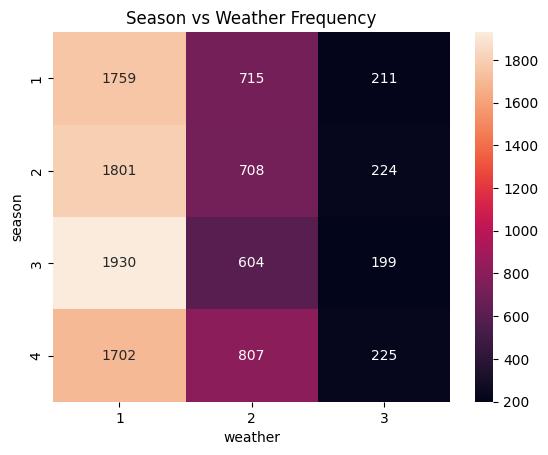

In [ ]:
sns.heatmap(cont_table2, annot=True, fmt='d')
plt.title("Season vs Weather Frequency")
plt.show()

**Observations for Chi-square test**

1. Statistical Significance: The test yielded an extremely low p-value of $1.55 \times 10^{-7}$, which is well below the 0.05 alpha, leading to a clear rejection of the Null Hypothesis ($H_0$).

2. Confirmed Dependency: With a Chi-square statistic of 49.16, we confirm a statistically significant dependency exists between weather patterns and seasonal changes.

3. Association Strength: Despite the high significance, a Cramer’s V of 0.046 indicates that the practical strength of the association between Season and Weather is very weak.

4. Data Consistency: After removing the rare Weather 4 category, the p-value remained significant at $2.82 \times 10^{-8}$, proving the dependency is robust and not driven by a single outlier.

5. Frequency Distribution: The contingency table shows Weather 1 (Clear) is most frequent across all seasons, peaking at 1,930 instances during Season 3.

6. Predictive Insight: While seasons and weather are statistically linked, the low Cramer's V suggests they should both be treated as distinct, independent predictors in a demand forecasting model.


# **Overall Observation**

1. The Commuter Anchor: Yulu serves as a vital daily utility, with demand peaking at 8 AM and 5-6 PM, showing that the service is a primary solution for the urban commute.

2. The Atmospheric Barrier: While users are loyal to the "time," they are highly sensitive to "conditions"; the service sees a 42% drop in rentals when moving from Clear (Weather 1) to Rain/Snow (Weather 3).

3. Calendar Neutrality: Surprisingly, the 2-Sample T-test confirmed that "Working Day" is not a major factor, with a negligible Cohen’s d of 0.025, proving that demand remains stable across the entire week.

4. The Seasonal Swing: Seasonal shifts are the biggest revenue drivers, with demand nearly doubling from an average of 116 rentals in Spring to 234 rentals in Fall.

# **Key Statistical Findings**

1. Seasonal Impact (ANOVA): Rejected $H_0$ with a p-value near 0, proving that seasons drastically change demand, with Fall (Season 3) providing the highest volume.

2. Weather Dependency (Chi-Square): Confirmed a statistical link between Season and Weather ($p < 0.05$), though a Cramer’s V of 0.046 suggests this association is weak in practice.

3. Environmental Sensitivity: Humidity shows a negative correlation, meaning as moisture levels rise, rentals reliably decline.

4. Multicollinearity Warning: A 0.98 correlation between temp and atemp indicates these variables are redundant and only one should be used for future predictive modeling.

5. Normality & Variance: All categories violated normality (Shapiro-Wilk $p < 0.05$), but the Levene’s test ($p = 0.94$) for working days showed variances were equal, validating the T-test comparison.

# **Recommendations & Required Actions**

1. Implement Weather-Based Dynamic Pricing: Introduce "Cloudy Day Discounts" or "Rainy Day Credits" to mitigate the 42% drop seen during inclement weather.

2. Optimize Fleet during Bimodal Peaks: Ensure maximum battery availability and vehicle density specifically during the 8 AM and 5-6 PM windows to capture peak commuter revenue.

3. Spring Subscription Push: Focus marketing spend on Season 1 (Spring) to counteract the lowest seasonal average of 116 rentals and lock in long-term users.

4. Hardware Improvements for Resilience: Market better tire traction and mudguards to assure commuters that the bikes are safe during Weather 2 (Misty) and Weather 3 (Rainy).

5. Ignore the "Workday" Bias: Stop differentiating marketing campaigns between weekdays and weekends; instead, pivot to hourly-based and weather-based targeting.

6. Simplify Data Modeling: Remove either temp or atemp from future business dashboards to reduce clutter and improve the speed of automated demand forecasts.